In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [31]:
df = pd.read_csv('../data/cs-training.csv')

#SeriousDlqin2yrs zmienna docelowa 

In [32]:
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [33]:
#usuwamy zbędną kolumne (błąd danych)

df = df.drop(columns = 'Unnamed: 0')

In [34]:
# Sprawdzamy podstawowe informacje na temat zbioru danych 

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

In [35]:
df.dtypes

SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

In [36]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [37]:
df.isna().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [38]:
# braki uzupełniamy medianą, średnia mogłaby zawyżyc wyniki ze względu na wartości odstające
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df["MonthlyIncome"].median())

In [39]:
# braki uzupełniamy modą, aby odzwierciedlić typowy profil klientów w danych.
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df["NumberOfDependents"].mode()[0])

In [40]:
duplikaty = df.duplicated()


In [41]:
df[duplikaty].head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1669,0,1.0,29,0,0.0,5400.0,0,0,0,0,0.0
3672,0,1.0,29,0,0.0,5400.0,0,0,0,0,0.0
7722,0,1.0,28,0,0.0,5400.0,0,0,0,0,0.0
7823,0,1.0,29,0,0.0,5400.0,0,0,0,0,0.0
7920,0,1.0,22,0,0.0,820.0,1,0,0,0,0.0


In [42]:
# dane sie powtarzają i nie ma ich dużo względem całego zbioru, dlatego je usuniemy 

df = df.drop_duplicates()

In [43]:
# sprawdzamy wszystkie kolumny prócz naszego celu który dzieli sie na 0 i 1
outliers = df.columns[1:]


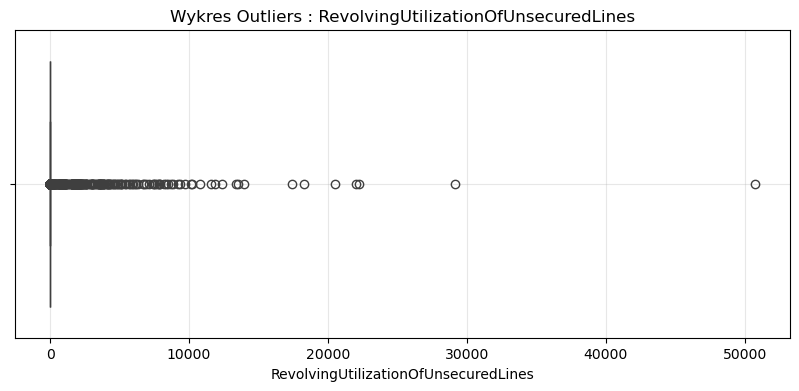

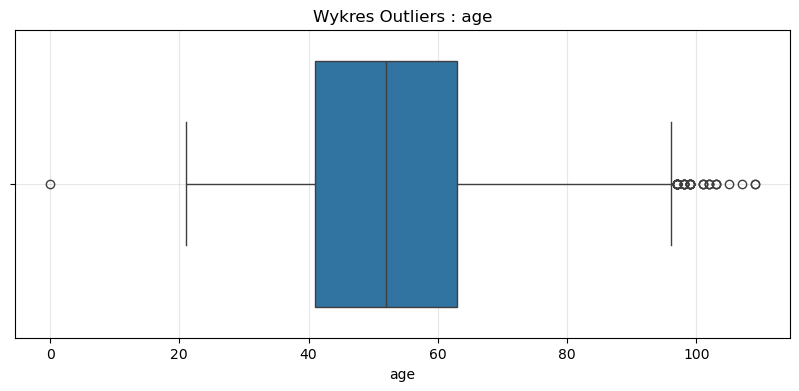

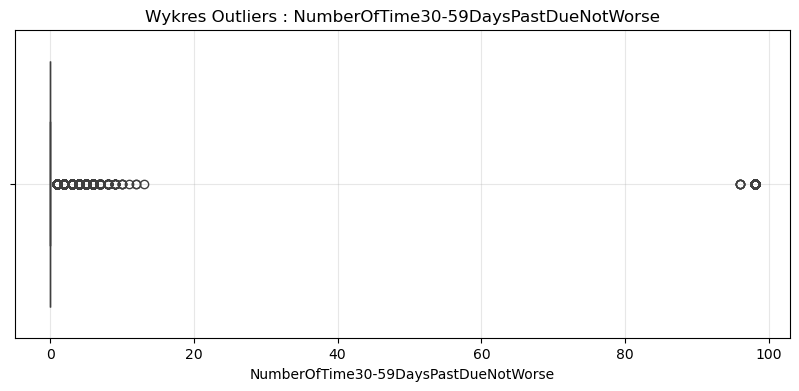

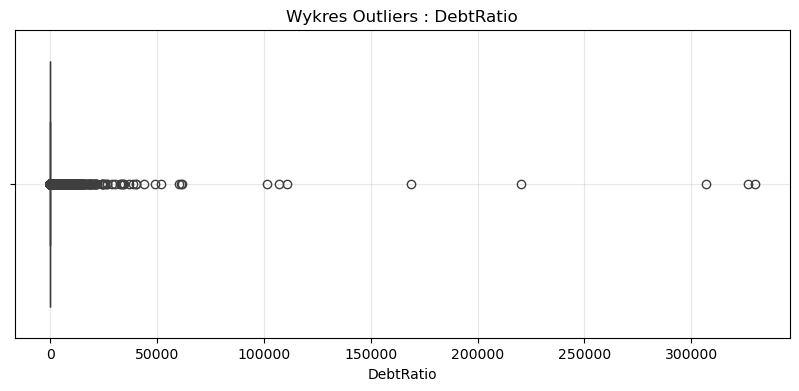

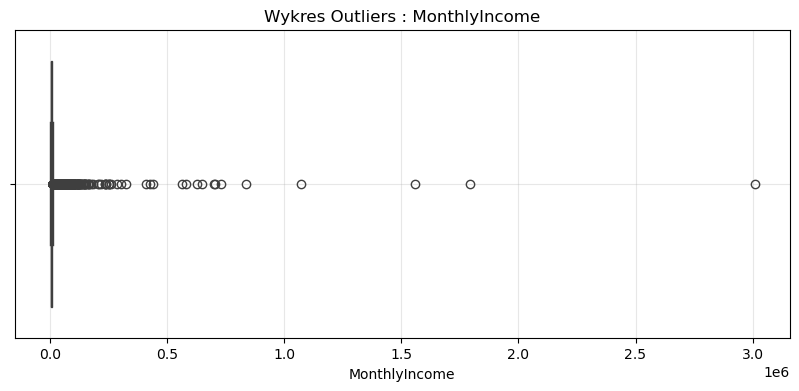

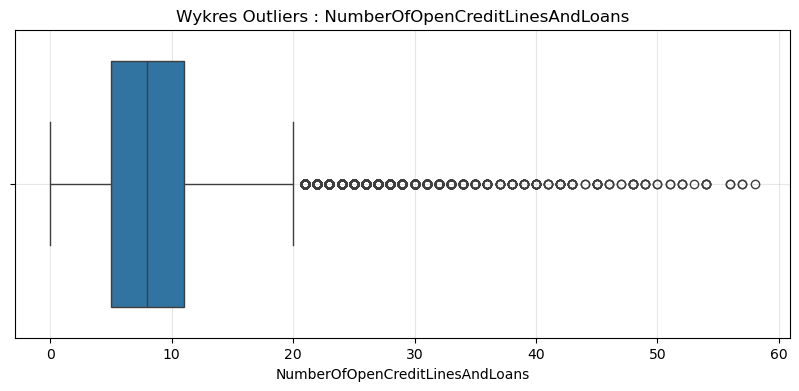

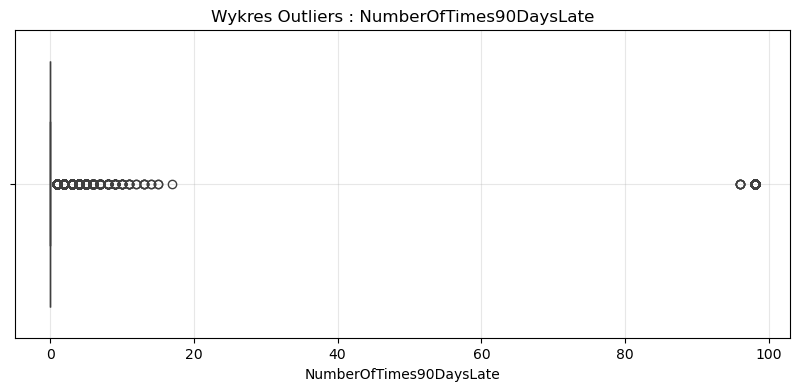

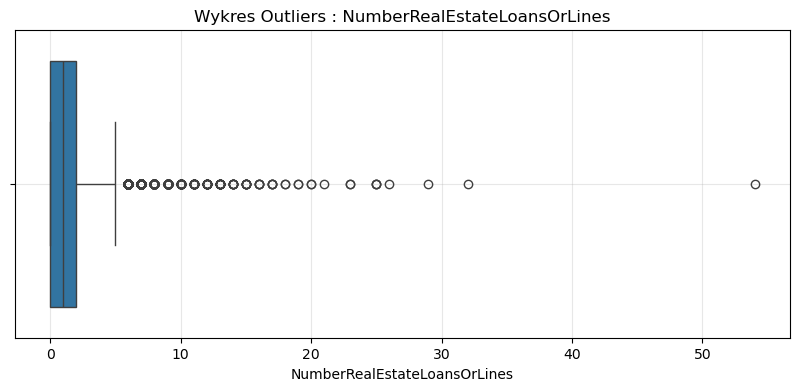

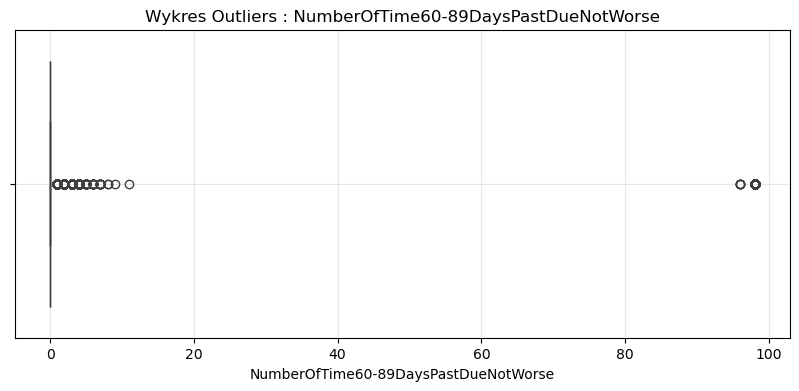

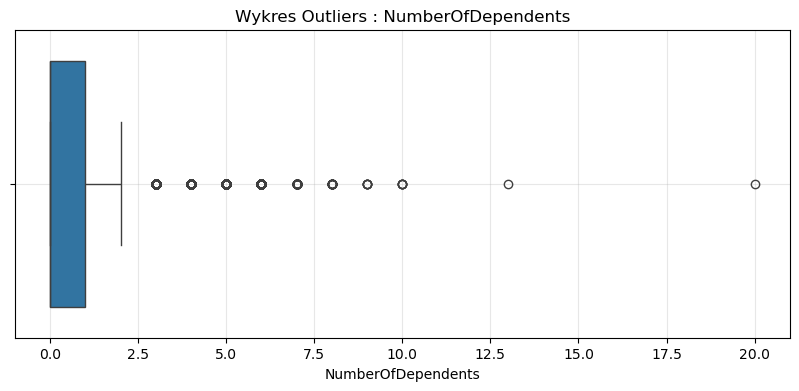

In [44]:
for col in outliers:    
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Wykres Outliers : {col}")
    plt.grid(alpha = 0.3)
    plt.show()

In [45]:
# wartośći w kolumnie są w zakresie od 0 do 1 więc używamy metody 'capowania',
# ponieważ oznaczają pełne lub nadmierne wykorzystanie limitu kredytowego tym samym
# ograniczymy wpływ wartości odstających na model i analize
df["RevolvingUtilizationOfUnsecuredLines"] = df["RevolvingUtilizationOfUnsecuredLines"].clip(upper=1)

In [46]:
# Zastosowałem metodę percentyli (1% i 99%), aby przyciąć liczbę otwartych kredytów. Pozwoliło to usunąć wartości odstające.
low_open = df['NumberOfOpenCreditLinesAndLoans'].quantile(0.01)
low_open = df['NumberOfOpenCreditLinesAndLoans'].quantile(0.01)
high_open = df['NumberOfOpenCreditLinesAndLoans'].quantile(0.99)

# Przycinamy 
df['NumberOfOpenCreditLinesAndLoans'] = df['NumberOfOpenCreditLinesAndLoans'].clip(lower=low_open, upper=high_open)

In [47]:
#Zastosowałem metodę percentyli (1% i 99%), aby przyciąć liczbę otwartych kredytów hipotecznych. Pozwoliło to usunąć wartości odstające.
low_open = df['NumberOfOpenCreditLinesAndLoans'].quantile(0.01)

low_real = df['NumberRealEstateLoansOrLines'].quantile(0.01)
high_real = df['NumberRealEstateLoansOrLines'].quantile(0.99)

# Przycinamy 
df['NumberRealEstateLoansOrLines'] = df['NumberRealEstateLoansOrLines'].clip(lower=low_real, upper=high_real)

In [48]:

# Usuwamy wartości odstające i przyjmujemy że wszystkie rodziny powyżej 5 traktujemy jak bardzo dużą rodzine
df["NumberOfDependents"] = df["NumberOfDependents"].clip(upper=5)

# Wiek ucinamy do przedziału 18 - 99 
df['age'] = df['age'].clip(lower=18, upper=df['age'].quantile(0.99))



In [49]:
# W kolumnach dotyczących spóźnień przyciąłem wartości  do  20. Pozwala to usunąć błędy , zachowując jednocześnie informację o tym, że dany klient jest w grupie wysokiego ryzyka.

cols_late = ['NumberOfTime30-59DaysPastDueNotWorse', 
             'NumberOfTimes90DaysLate', 
             'NumberOfTime60-89DaysPastDueNotWorse']


for col in cols_late:
    df[col] = df[col].clip(upper=20)

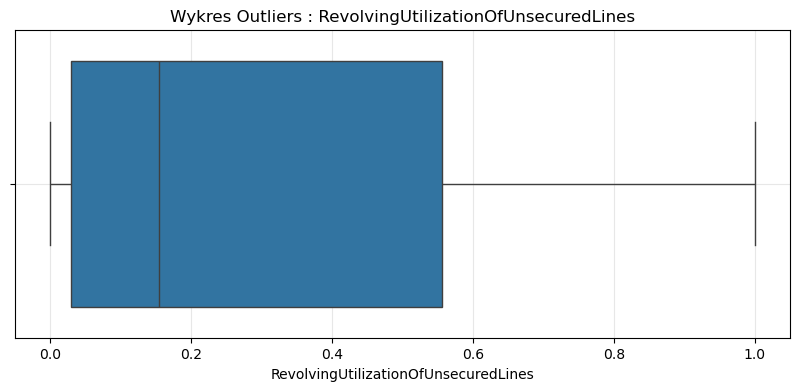

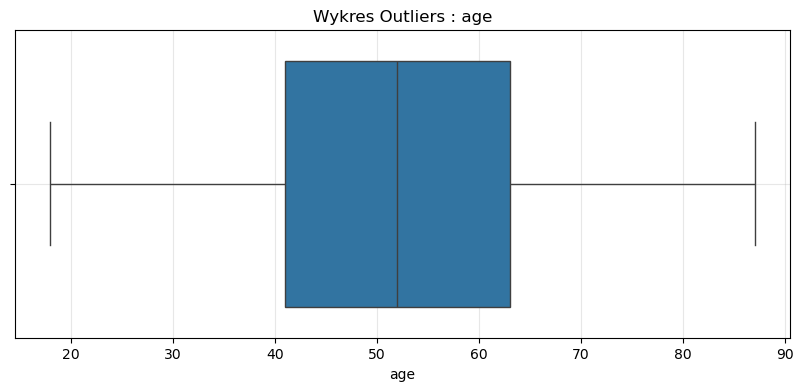

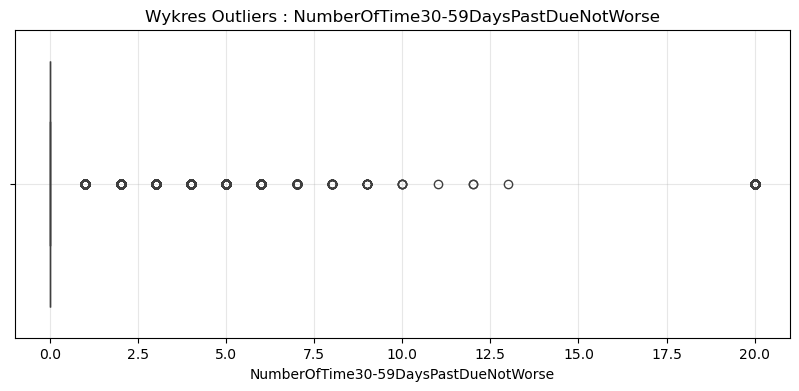

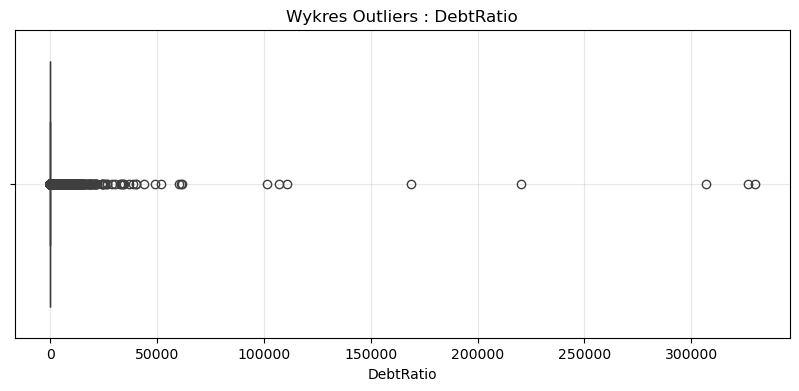

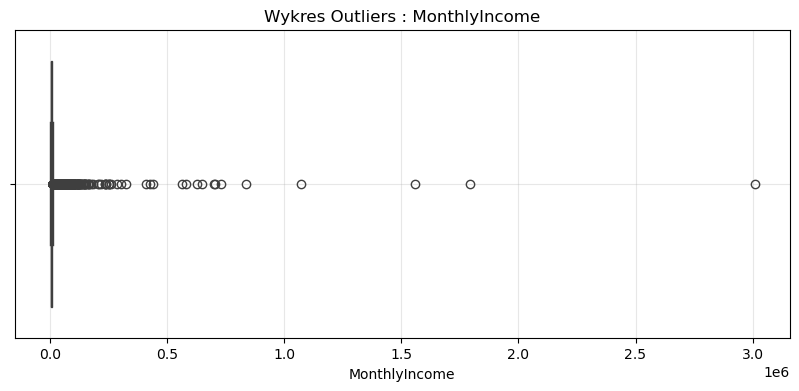

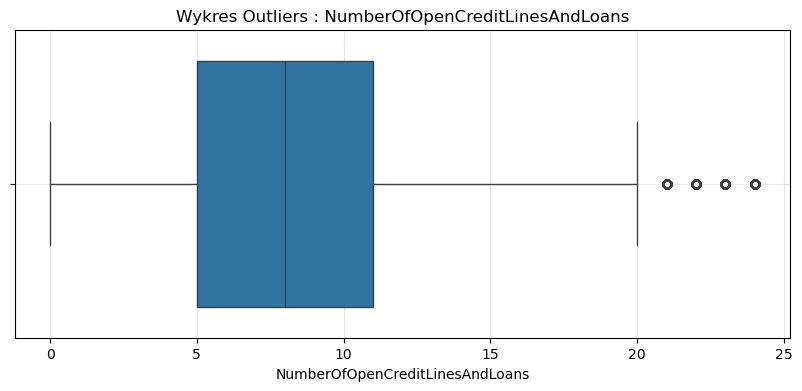

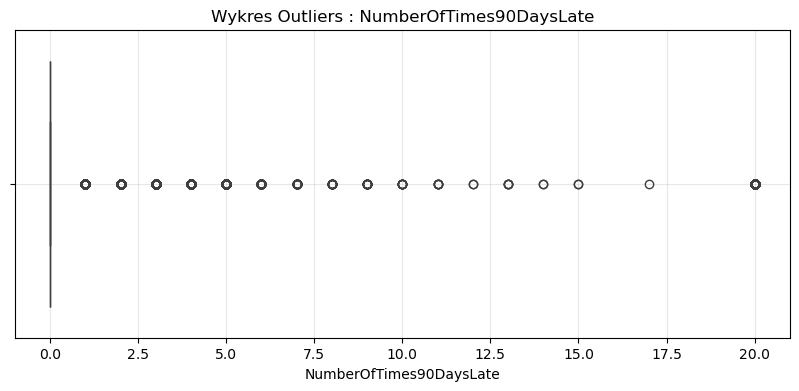

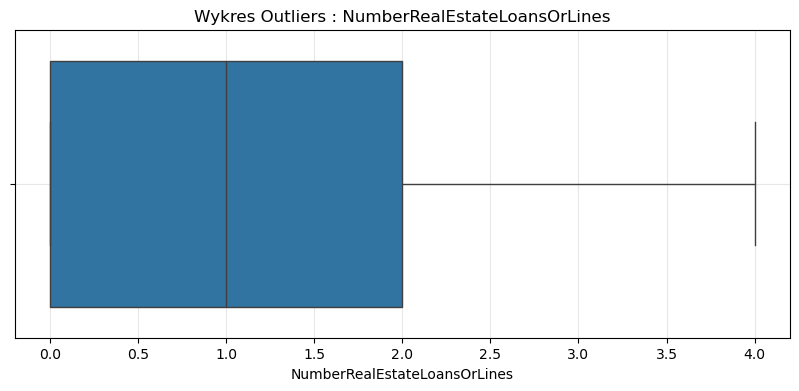

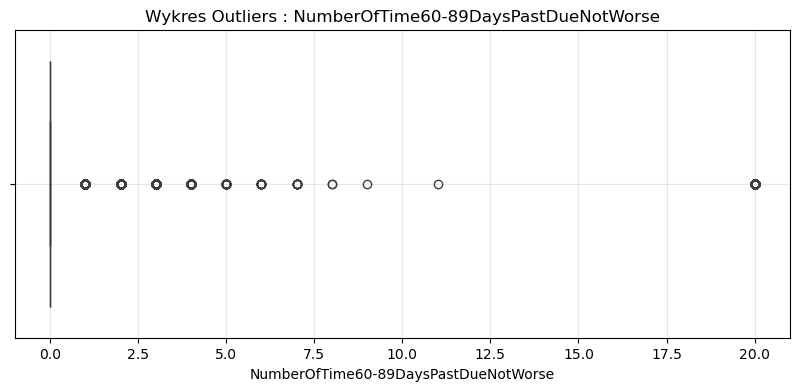

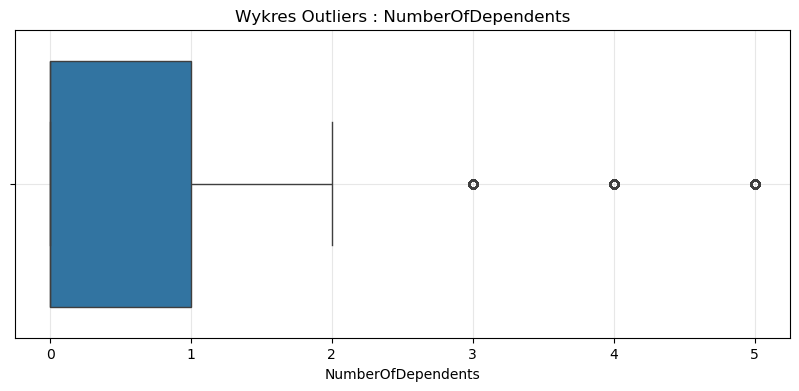

In [50]:
for col in outliers:    
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df, x=col)
    plt.title(f"Wykres Outliers : {col}")
    plt.grid(alpha = 0.3)
    plt.show()

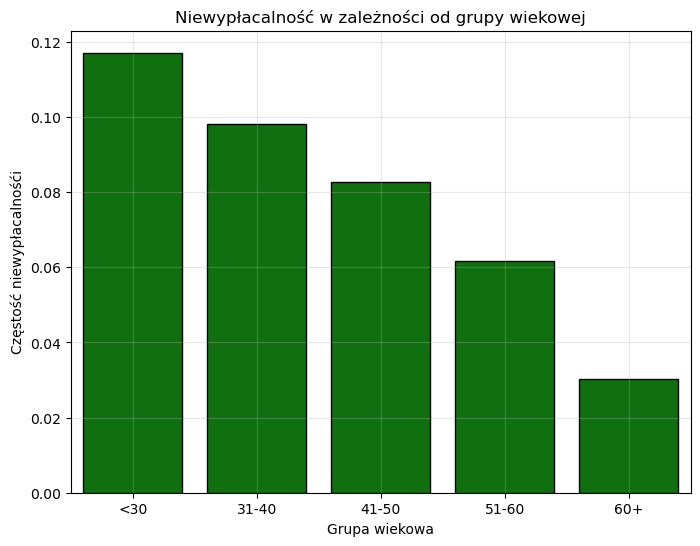

In [51]:
# tworzymy nową kolumnę i grupujemy klientów według wieku 

bins = [0,30, 40, 50, 60, 100]
labels = ['<30', '31-40', '41-50', '51-60', '60+']
df['Age_Group'] = pd.cut(df['age'], bins=bins, labels=labels)

# tworzymy wykres przedstawiający która niewypłacalność względem grupy wiekowej 
# czy wiek klienta ma wpływ na ryzko niewypłacolności?


plt.figure(figsize=(8,6))
sns.barplot(
    data=df,
    x = 'Age_Group',
    y= 'SeriousDlqin2yrs',
    edgecolor='black',
    color = 'green',
    errorbar=None)

plt.xlabel('Grupa wiekowa')
plt.ylabel('Częstość niewypłacalnośći')
plt.title('Niewypłacalność w zależności od grupy wiekowej')
plt.grid(alpha = 0.3)
plt.savefig('../images/niewyplacolnosc_grupa_wiek.png', dpi=300, bbox_inches='tight')
plt.show()

Podzieliłem klientów na 5 grup wiekowych, aby sprawdzić jak etap życia wpływa na ryzyko kredytowe, 
jak można zauważyć ryzyko niewypłacalności maleje raz z wiekiem czyli najbardziej rzetelnymi płatnikami są osoby powyżej 60 roku życia, natomiast najwyższszy odsetek niewypłacallności panuje w grupie poniżej 30 roku życia co może być związane z niższymi dochodami lub mniejszym doświaczeniem w zarządzaniu budżetem.

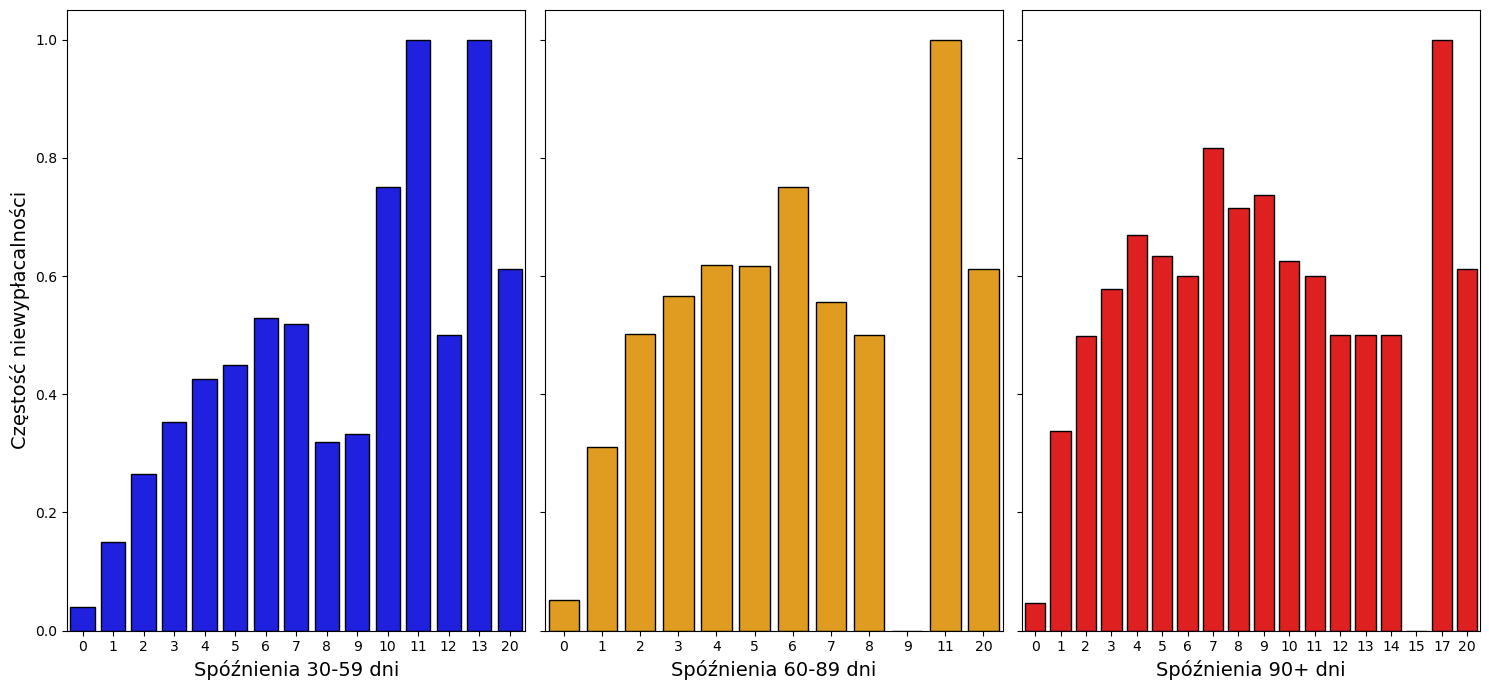

In [52]:
# Czy historia opoźnień jest sygnałem niewypłacalności?

fig, axes  = plt.subplots(1,3, figsize = (15, 7), sharey= True)

# pierwszy wykres 
sns.barplot(
    data= df,
    ax = axes[0],
    x = 'NumberOfTime30-59DaysPastDueNotWorse',
    y = 'SeriousDlqin2yrs',
    color = 'blue',
    edgecolor = 'black',
    errorbar= None
)
axes[0].set_xlabel('Spóźnienia 30-59 dni', fontsize = 14)
axes[0].set_ylabel('Częstość niewypłacalności', fontsize=14)
# drugi wykres 

sns.barplot(
    data= df,
    ax = axes[1],
    x = 'NumberOfTime60-89DaysPastDueNotWorse',
    y = 'SeriousDlqin2yrs',
    color = 'orange',
    edgecolor = 'black',
    errorbar= None
)
axes[1].set_xlabel('Spóźnienia 60-89 dni', fontsize = 14)
# trzeci wykres 
sns.barplot(
    data= df,
    ax = axes[2],
    x = 'NumberOfTimes90DaysLate',
    y = 'SeriousDlqin2yrs',
    color = 'red',
    edgecolor = 'black',
    errorbar= None
)
axes[2].set_xlabel('Spóźnienia 90+ dni', fontsize = 14)

plt.tight_layout()
plt.savefig('../images/czestosc_niewyplacalnosc30_90.png', dpi=300, bbox_inches='tight')
plt.show()

Jak na można zauważyć na powyższym wykresie istnieje korelacja pomiędzy spóźnioną płatnościa a niewypłacalonością, najstoniejszym predyktorem ryzka braku spłaty zobowiązania jest wykres powyżej 90 dni gdzie nawet jeden przypadek takiego spóźnienia znacząco podnosi ryzyko niewypłacalności.

W przypadku opóźnień 30-59 dni wzrost ryzyka jest bardziej stopniowy co może byc krótkim spoźnieniem a nie trwałym brakiem płynności.

Wartości powyżej 10 opóźnień s są rzadkie ale niemal zawszę wiążą się z wysokim ryzkiem.

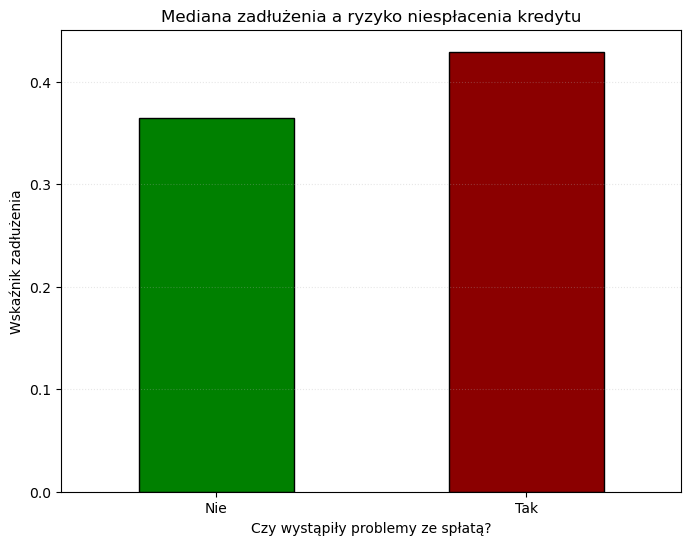

In [53]:
# Jak zadłużenie wpływa na na ryzyko niespłacenia?

plt.figure(figsize=(8,6))

# tworzymy wykres, w tym wypadku używamy mediany żeby był bardziej odporny na wartości odstające 

ax = df.groupby(by = 'SeriousDlqin2yrs')['DebtRatio'].median().plot(
    kind = 'bar',
    color = [ 'green', 'darkred'],
    edgecolor = 'black'
)


plt.xticks([0, 1], ['Nie', 'Tak'], rotation=0)
plt.xlabel('Czy wystąpiły problemy ze spłatą?')
plt.ylabel('Wskaźnik zadłużenia')
plt.title('Mediana zadłużenia a ryzyko niespłacenia kredytu')
plt.grid(axis='y', linestyle=':', alpha=0.3)
plt.savefig('../images/media_zadluzenia_aniesplata.png', dpi=300, bbox_inches='tight')
plt.show()

Jak można zauważyć na powyższym wykresie, zastosowanie mediany pozwoliło wyeliminować wpływ wartości ekstremalnych. Wykres pokazuje, że osoby niewypłacalne charakteryzują się wyższym poziomem zadłużenia w stosunku do dochodów, co jest silnym sygnałem ostrzegawczym w ocenie ryzyka.

In [54]:
# dzielimy klientów na grupy w zalezności od wynagrodzenia

bins = [0,3000, 5000, 10000, float('inf')]
labels = ['niski dochód ', 'średni - niższy', 'średni - wyższy', 'wysoki dochód']
df['Income_Group'] = pd.cut(df['MonthlyIncome'], bins=bins, labels=labels)


C:\Users\Thinkpad\AppData\Local\Temp\ipykernel_23000\1815563553.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


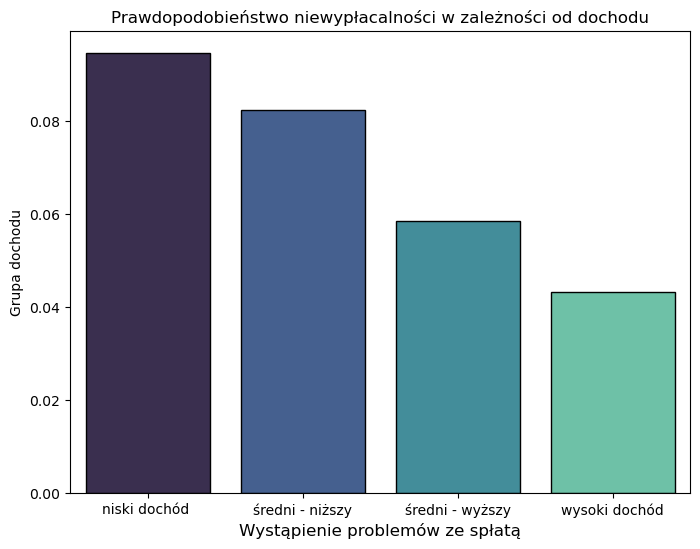

In [55]:
# worzymy wykres, który odpowie na pytanie czy dochód klienta wpływa na jakość spłaty?

plt.figure(figsize=(8,6))

sns.barplot(
    data = df,
    x= 'Income_Group',
    y = 'SeriousDlqin2yrs',
    palette= 'mako',
    errorbar= None,
    edgecolor = 'black'
)

plt.xlabel('Wystąpienie problemów ze spłatą', fontsize = 12)
plt.ylabel('Grupa dochodu')
plt.title('Prawdopodobieństwo niewypłacalności w zależności od dochodu')
plt.savefig('../images/prawdpodbienstwo_niewyplacalnosc_od_dochodu.png', dpi=300, bbox_inches='tight')
plt.show()



Największy spadek ryzko niewypłacalności możemy zauważyć przy przejściu z grupy średni niższy do sredni wyższy. 
Sugeruje to, że przekroczenie pewnego progu dochodowego, jest kluczowe dla stabliności finansowej. 
Wyższy dochód zapewnia większą 'poduszkę finansową' , który pozwala na obsługe spłat nawet w nieprzewidzianych sytuacjach.

In [56]:
# Jak wygląda klient idealny?

# tworzymy tabele przestawną 

klient_idealny = df.pivot_table(
    index='Income_Group', 
    columns= 'Age_Group',
    values='SeriousDlqin2yrs', 
    aggfunc='mean'
)

print(klient_idealny)

Age_Group             <30     31-40     41-50     51-60       60+
Income_Group                                                     
niski dochód     0.129444  0.122309  0.115019  0.085135  0.043809
średni - niższy  0.103028  0.112186  0.104568  0.087203  0.033187
średni - wyższy  0.116906  0.086604  0.075486  0.055973  0.026846
wysoki dochód    0.096774  0.069301  0.056852  0.039881  0.024053


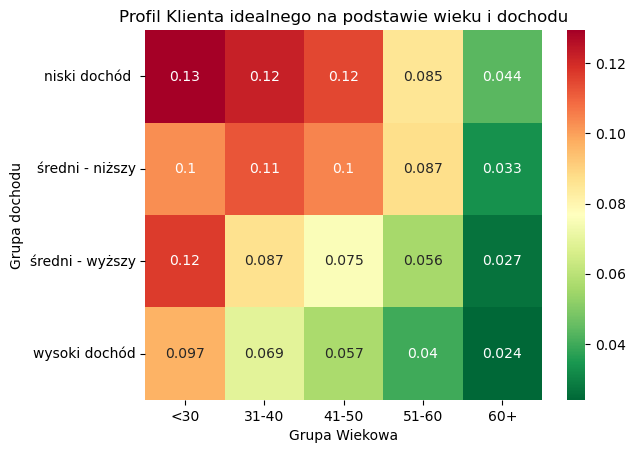

In [57]:

sns.heatmap(klient_idealny, annot=True, cmap="RdYlGn_r")
plt.xlabel('Grupa Wiekowa')
plt.ylabel('Grupa dochodu')
plt.title('Profil Klienta idealnego na podstawie wieku i dochodu')
plt.savefig('../images/heatmpa_klientidealny.png', dpi=300, bbox_inches='tight')
plt.show()

Po powyzszej mapie ciepła możemy wywnioskować, że stabliność finansowa rośnie wraz z wiekiem, niezależenie od grupy dochodowej, kluczowym spostrzeżeniem jest fakt, żę klienci grupy '60+' wskazują niskie ryzko nawet przy najniższych dochodach, podczas gdy wysokie zarobki u osób poniżej 30 roku życia nie niewelują ryzyka w stopniu tak znaczącym jak robi to wiek.
Na wykresie widać też osoby 31-40 z niskim dochodem (12%). To prawdopodobnie grupa najbardziej obciążona życiowo (młode rodziny, pierwsze duże kredyty), co przy niskich zarobkach czyni ich bardzo wrażliwymi na ryzko braku płynności finansowej.

In [62]:
# zapisujemy dane do modelowania

df.to_csv('../data/data_for_model.csv', index = False) 
